# Analytical and Numerical Methods for the Black-Scholes Equation in European Option Pricing

This notebook reproduces the numerical experiments used in the report. The finite difference methods solve the original Black-Scholes PDE in the time-to-maturity variable $\theta = T - t$. Crank-Nicolson is the main numerical method. Explicit Euler is imported as a simple educational method, but it is conditionally stable and is not used for the final results.

## A. Imports and configuration

In [1]:
from pathlib import Path
import sys

sys.dont_write_bytecode = True

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PLOT_FIGSIZE = (8.0, 5.0)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from black_scholes_pde import (
    BlackScholesParams,
    GridParams,
    black_scholes_price,
    comparison_table,
    convergence_table,
    error_metrics,
    market_chain_comparison_table,
    parameter_sensitivity,
    payoff,
    solve_crank_nicolson_fd,
    solve_explicit_fd,
)
from black_scholes_pde.visualization import (
    plot_convergence,
    plot_error,
    plot_parameter_sensitivity,
    plot_payoff_vs_exact,
    plot_price_comparison,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": PLOT_FIGSIZE,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "semibold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "font.size": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.facecolor": "white",
        "legend.edgecolor": "#dddddd",
        "lines.linewidth": 2.2,
        "lines.markersize": 5,
        "grid.color": "#d9dde3",
        "grid.linewidth": 0.8,
    }
)

def polish_figure(fig):
    fig.set_size_inches(*PLOT_FIGSIZE, forward=True)
    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        ax.set_facecolor("white")
        ax.grid(True, color="#d9dde3", linewidth=0.8, alpha=0.8)
        for spine in ax.spines.values():
            spine.set_color("#333333")
            spine.set_linewidth(0.8)
    fig.tight_layout()

def save_figure(fig, filename):
    polish_figure(fig)
    fig.savefig(FIGURES_DIR / filename)

## B. Baseline parameters

The main example is a European call option with strike $K=100$, maturity $T=1$, interest rate $r=0.05$, volatility $\sigma=0.20$, and truncated asset domain $0 \leq s \leq 200$.

In [2]:
params = BlackScholesParams(
    strike=100,
    maturity=1,
    rate=0.05,
    volatility=0.20,
    option_type="call",
)
grid = GridParams(s_max=200, asset_steps=400, time_steps=400)
asset_grid = np.linspace(0.0, grid.s_max, grid.asset_steps + 1)
payoff_values = payoff(asset_grid, params.strike, params.option_type)
exact = black_scholes_price(asset_grid, params)

## C. Payoff vs exact Black-Scholes price

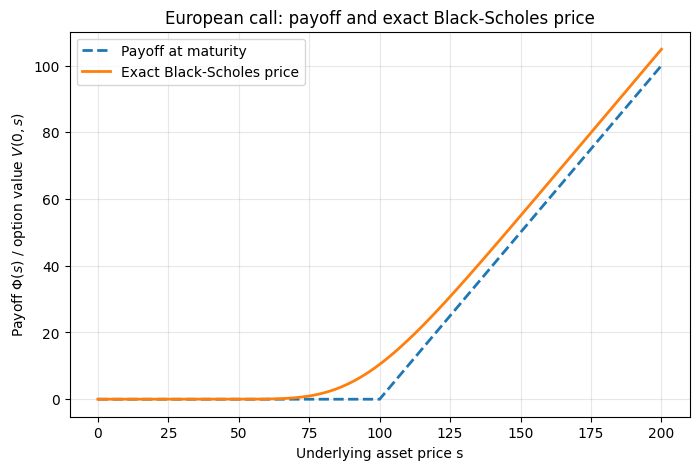

In [3]:
fig, ax = plot_payoff_vs_exact(
    asset_grid,
    exact,
    payoff_values,
    title="European call: payoff and exact Black-Scholes price",
)
save_figure(fig, "payoff_vs_exact_call.png")
plt.show()

## D. Crank-Nicolson solution

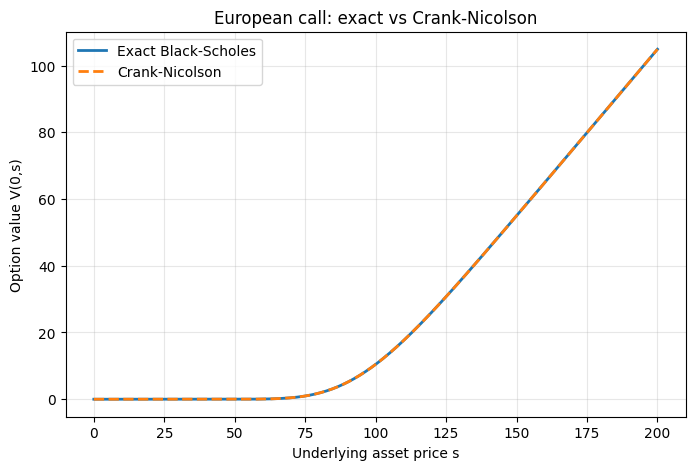

In [4]:
asset_grid, numerical = solve_crank_nicolson_fd(params, grid)
exact = black_scholes_price(asset_grid, params)

fig, ax = plot_price_comparison(
    asset_grid,
    numerical,
    exact,
    title="European call: exact vs Crank-Nicolson",
)
save_figure(fig, "exact_vs_crank_nicolson_call.png")
plt.show()

## E. Evolution of the finite difference solution

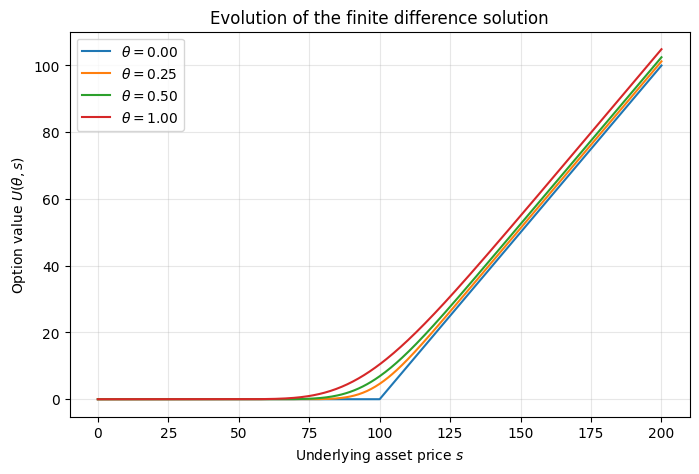

In [5]:
asset_grid, theta_grid, solution = solve_crank_nicolson_fd(
    params,
    grid,
    return_full_grid=True
)

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

for theta_value in [0.0, 0.25, 0.5, 1.0]:
    idx = np.argmin(np.abs(theta_grid - theta_value))
    ax.plot(asset_grid, solution[idx], label=f"$\\theta={theta_grid[idx]:.2f}$")

ax.set_xlabel("Underlying asset price $s$")
ax.set_ylabel("Option value $U(\\theta,s)$")
ax.set_title("Evolution of the finite difference solution")
ax.grid(True, alpha=0.3)
ax.legend()

save_figure(fig, "pde_solution_evolution_call.png")
plt.show()

## F. Absolute error plot

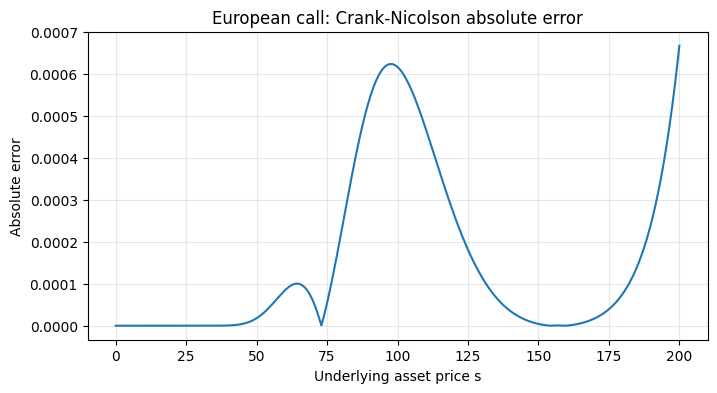

In [6]:
fig, ax = plot_error(
    asset_grid,
    numerical,
    exact,
    title="European call: Crank-Nicolson absolute error",
)
save_figure(fig, "absolute_error_call.png")
plt.show()

## F. Error metrics

In [7]:
call_error_metrics = error_metrics(numerical, exact)
call_error_metrics

{'max_abs_error': 0.000666684395113748,
 'mae': 0.00015209489829068137,
 'rmse': 0.0002513981329337442}

## G. Comparison table for selected asset prices

In [8]:
selected_prices = comparison_table([80, 100, 120], params, grid)
selected_prices

,asset_price,exact_price,numerical_price,absolute_error
0,80.0,1.859420,1.859199,0.000221
1,100.0,10.450584,10.449968,0.000616
2,120.0,26.169044,26.168778,0.000266


## H. Grid convergence analysis

In [9]:
convergence = convergence_table(
    params,
    grid_sizes=[(50, 50), (100, 100), (200, 200), (400, 400)],
    s_max=200,
)
convergence

,asset_steps,time_steps,max_abs_error,mae,rmse
0,50,50,0.039918,0.007632,0.014458
1,100,100,0.009985,0.001947,0.003625
2,200,200,0.002493,0.000512,0.000914
3,400,400,0.000667,0.000152,0.000251


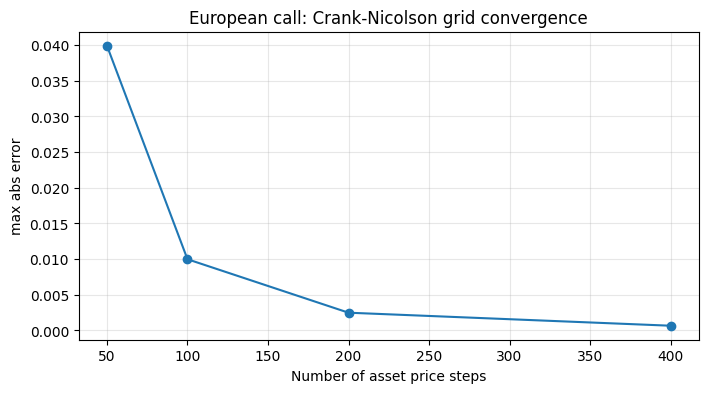

In [10]:
fig, ax = plot_convergence(
    convergence,
    metric="max_abs_error",
    title="European call: Crank-Nicolson grid convergence",
)
save_figure(fig, "grid_convergence_call.png")
plt.show()

## I. Parameter sensitivity analysis

The following plots use the exact Black-Scholes formula so each parameter effect is shown without numerical discretization error.

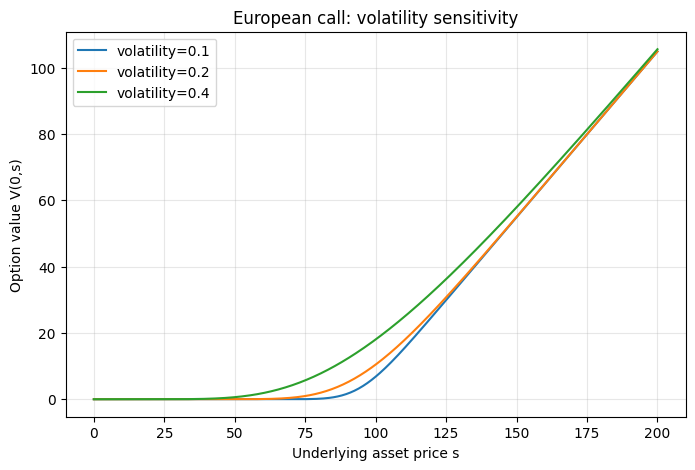

In [11]:
sensitivity_asset_grid = np.linspace(0.0, grid.s_max, grid.asset_steps + 1)

volatility_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "volatility", [0.10, 0.20, 0.40]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, volatility_curves, "volatility",
    title="European call: volatility sensitivity",
)
save_figure(fig, "volatility_sensitivity_call.png")
plt.show()

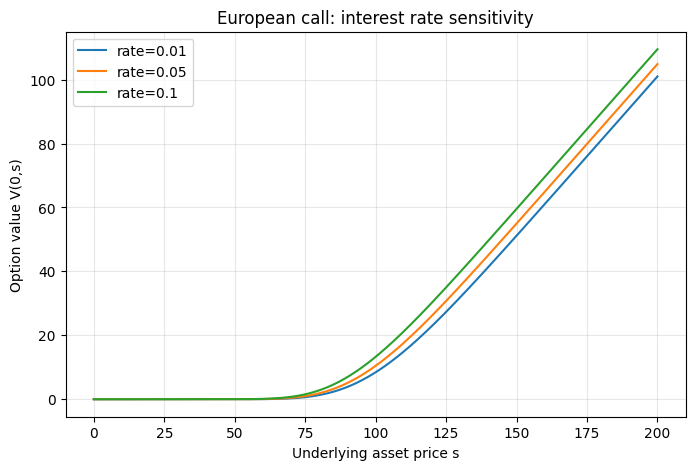

In [12]:
rate_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "rate", [0.01, 0.05, 0.10]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, rate_curves, "interest rate",
    title="European call: interest rate sensitivity",
)
save_figure(fig, "rate_sensitivity_call.png")
plt.show()

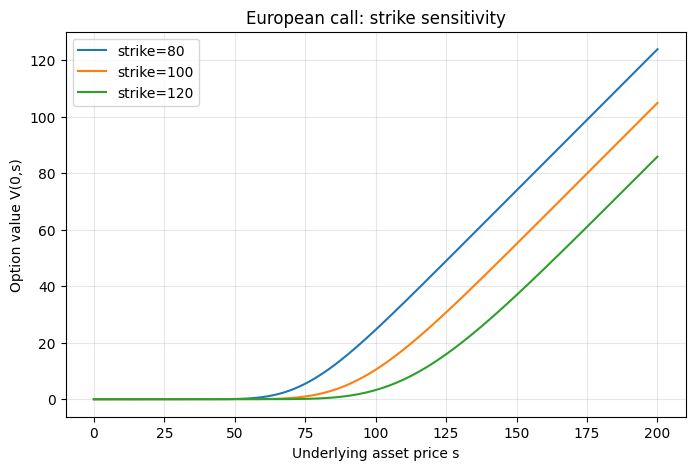

In [13]:
strike_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "strike", [80, 100, 120]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, strike_curves, "strike",
    title="European call: strike sensitivity",
)
save_figure(fig, "strike_sensitivity_call.png")
plt.show()

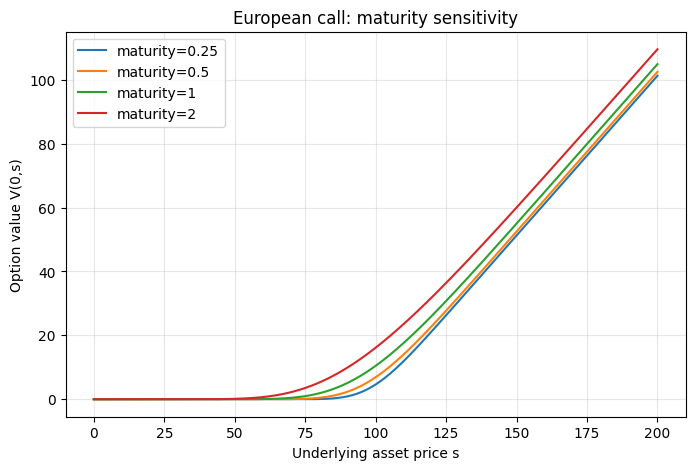

In [14]:
maturity_curves = parameter_sensitivity(
    sensitivity_asset_grid, params, "maturity", [0.25, 0.5, 1.0, 2.0]
)
fig, ax = plot_parameter_sensitivity(
    sensitivity_asset_grid, maturity_curves, "maturity",
    title="European call: maturity sensitivity",
)
save_figure(fig, "maturity_sensitivity_call.png")
plt.show()

## J. Optional European put example

{'max_abs_error': 0.0006666843951132276,
 'mae': 0.00015209754553619,
 'rmse': 0.00025140090245230205}

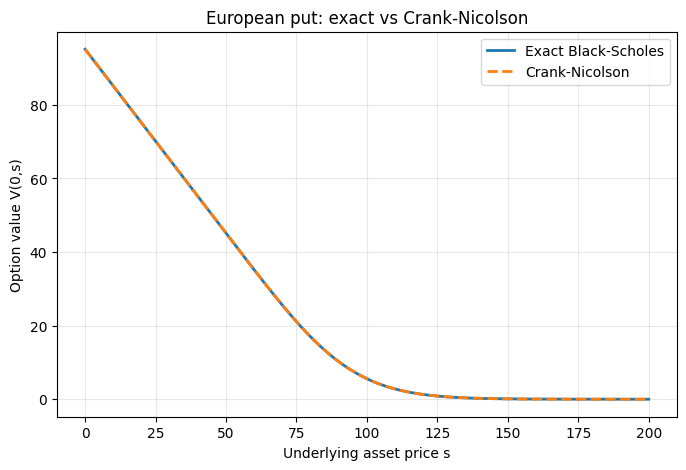

In [15]:
put_params = BlackScholesParams(
    strike=100,
    maturity=1,
    rate=0.05,
    volatility=0.20,
    option_type="put",
)
put_asset_grid, put_numerical = solve_crank_nicolson_fd(put_params, grid)
put_exact = black_scholes_price(put_asset_grid, put_params)

fig, ax = plot_price_comparison(
    put_asset_grid,
    put_numerical,
    put_exact,
    title="European put: exact vs Crank-Nicolson",
)
save_figure(fig, "exact_vs_crank_nicolson_put.png")
plt.show()

put_error_metrics = error_metrics(put_numerical, put_exact)
put_error_metrics

## K. Practical market comparison: BTCUSDT options

A one-contract comparison is too weak for a market section. One quote can be distorted by a particular strike, expiry, or bid-ask spread. Here we use the saved BTCUSDT option-chain CSV as a cross-section: many calls and puts, several strikes, and several expiries within roughly the next month.

The data are loaded from CSV files generated by `scripts/fetch_btcusdt_option_snapshot.py`. The script uses public Binance market-data endpoints only, so no Binance API key, account, or `.env` file is required.


We compare market option prices with the same Black-Scholes formula used earlier in the notebook. For each contract:

$$m = \frac{S_0}{K}$$

where `m` is moneyness, `S_0` is the BTCUSDT index price, and `K` is the strike. Values above 1 mean that the underlying is above the strike; values below 1 mean that the underlying is below the strike.

The model error used below is

$$error = V_{BS} - V_{market}.$$

We now use four volatility inputs:

1. `mark_iv_binance` - Binance mark implied volatility from the option quote.
2. `close_to_close` - annualized volatility from daily close-to-close log returns.
3. `german_klass` - the Garman-Klass OHLC volatility estimator, kept under this label in the tables.
4. `rogers_satchell` - the Rogers-Satchell OHLC volatility estimator.

For market context, Binance describes implied volatility as a forward-looking measure derived from option prices, reflecting the market expectation of future price movement over the life of the option. Binance also discusses IV skew: implied volatility can differ across strikes and expiries because of supply, demand, sentiment, and event risk. Source: [Binance Blog, Understanding the Crypto Options Data Page on Binance](https://www.binance.com/en/blog/futures/722896077045740044).

The historical estimators are based on the saved BTCUSDT daily candles:

$$\sigma_{cc} = \sqrt{365}\, std\left(\log\left(\frac{C_t}{C_{t-1}}\right)\right),$$

$$\sigma_{GK}^2 = 365\, mean\left[\frac{1}{2}\log\left(\frac{H_t}{L_t}\right)^2 - (2\log 2 - 1)\log\left(\frac{C_t}{O_t}\right)^2\right],$$

$$\sigma_{RS}^2 = 365\, mean\left[\log\left(\frac{H_t}{O_t}\right)\log\left(\frac{H_t}{C_t}\right) + \log\left(\frac{L_t}{O_t}\right)\log\left(\frac{L_t}{C_t}\right)\right].$$


In [16]:
chain_path = PROJECT_ROOT / "data" / "btcusdt_option_chain_snapshot.csv"
btc_chain_snapshot = pd.read_csv(chain_path)

def report_table(frame):
    return frame.style.hide(axis="index")

def format_usdt(value):
    return "" if pd.isna(value) else f"{value:,.2f}"

def format_signed_usdt(value):
    return "" if pd.isna(value) else f"{value:,.2f}"

def format_percent(value):
    return "" if pd.isna(value) else f"{value:.2%}"

snapshot_time = pd.to_datetime(
    btc_chain_snapshot["observed_at_utc"].iloc[0], utc=True
)
spot_price = btc_chain_snapshot["underlying_price"].iloc[0]

snapshot_summary = pd.DataFrame(
    {
        "Snapshot date": [snapshot_time.strftime("%Y-%m-%d %H:%M UTC")],
        "BTCUSDT index": [f"{spot_price:,.2f}"],
        "Contracts": [btc_chain_snapshot["symbol"].nunique()],
        "Expiries": [btc_chain_snapshot["expiry_utc"].nunique()],
        "Calls / puts": [
            f"{(btc_chain_snapshot['option_type'] == 'call').sum()} / "
            f"{(btc_chain_snapshot['option_type'] == 'put').sum()}"
        ],
        "Maturity range": [
            f"{btc_chain_snapshot['maturity_days'].min():.1f}-"
            f"{btc_chain_snapshot['maturity_days'].max():.1f} days"
        ],
    }
)

volatility_input_summary = pd.DataFrame(
    {
        "Volatility input": [
            "mark_iv_binance",
            "close_to_close",
            "german_klass",
            "rogers_satchell",
        ],
        "Annualized volatility": [
            f"{btc_chain_snapshot['mark_iv_binance'].mean():.2%} mean "
            f"({btc_chain_snapshot['mark_iv_binance'].min():.2%}-"
            f"{btc_chain_snapshot['mark_iv_binance'].max():.2%})",
            format_percent(btc_chain_snapshot["close_to_close"].iloc[0]),
            format_percent(btc_chain_snapshot["german_klass"].iloc[0]),
            format_percent(btc_chain_snapshot["rogers_satchell"].iloc[0]),
        ],
        "Source": [
            "Binance option mark IV",
            "daily close prices",
            "daily OHLC range",
            "daily OHLC, drift-robust",
        ],
    }
)

display(report_table(snapshot_summary))
report_table(volatility_input_summary)


Snapshot date,BTCUSDT index,Contracts,Expiries,Calls / puts,Maturity range
2026-06-06 18:37 UTC,"60,577.11",294,6,147 / 147,0.6-19.6 days


Volatility input,Annualized volatility,Source
mark_iv_binance,65.26% mean (44.20%-116.00%),Binance option mark IV
close_to_close,42.95%,daily close prices
german_klass,45.98%,daily OHLC range
rogers_satchell,46.39%,"daily OHLC, drift-robust"


This snapshot contains **294 option contracts** across **6 expiries**, with an equal split between **147 calls** and **147 puts**. The available maturities range from **0.6 to 19.6 days**, so the market comparison focuses on short-term BTCUSDT options.

The important change is that we no longer compare Binance IV with only one historical volatility estimate. The simple `close_to_close` estimate is **42.95%**, while the OHLC estimators are slightly higher: **45.98%** for `german_klass` and **46.39%** for `rogers_satchell`. The average Binance mark IV is much higher at **65.26%**, and it varies by contract from **44.20%** to **116.00%**. This already suggests that the option market is pricing a richer volatility structure than one constant historical number.


After checking the data coverage, we price every contract in the snapshot with the Black-Scholes formula. Each option is priced four times, once for each volatility input. The table below summarizes the pricing error across all **294 contracts**.

We use median errors because the option chain contains many strikes, and extreme out-of-the-money contracts can otherwise make the summary less readable.


In [17]:
volatility_order = [
    "mark_iv_binance",
    "close_to_close",
    "german_klass",
    "rogers_satchell",
]
source_labels = {source: source for source in volatility_order}
historical_inputs = ["close_to_close", "german_klass", "rogers_satchell"]

fd_candidates = (
    btc_chain_snapshot.assign(
        atm_distance=(btc_chain_snapshot["moneyness"] - 1.0).abs()
    )
    .sort_values(["expiry_utc", "option_type", "atm_distance"])
    .groupby(["expiry_utc", "option_type"], as_index=False)
    .head(1)
    .sort_values(["maturity_days", "option_type"])
    .head(8)
)
fd_symbols = set(fd_candidates["symbol"])

btc_chain_comparison = market_chain_comparison_table(
    btc_chain_snapshot,
    volatility_columns=tuple(volatility_order),
    fd_symbols=fd_symbols,
)

model_summary = (
    btc_chain_comparison.groupby("volatility_source")
    .agg(
        contracts=("symbol", "nunique"),
        mean_volatility=("volatility", "mean"),
        median_abs_error=("absolute_model_error", "median"),
        mean_abs_error=("absolute_model_error", "mean"),
        median_relative_error=("relative_model_error", "median"),
        median_bid_ask_spread=("bid_ask_spread", "median"),
    )
    .reset_index()
    .assign(order=lambda df: df["volatility_source"].map({name: i for i, name in enumerate(volatility_order)}))
    .sort_values("order")
)

model_summary_display = pd.DataFrame(
    {
        "Volatility input": model_summary["volatility_source"],
        "Contracts": model_summary["contracts"].astype(int),
        "Mean volatility": model_summary["mean_volatility"].map(format_percent),
        "Median |BS - market|": model_summary["median_abs_error"].map(format_usdt),
        "Mean |BS - market|": model_summary["mean_abs_error"].map(format_usdt),
        "Median relative error": model_summary["median_relative_error"].map(format_percent),
        "Median bid-ask spread": model_summary["median_bid_ask_spread"].map(format_usdt),
    }
)

report_table(model_summary_display)


Volatility input,Contracts,Mean volatility,Median |BS - market|,Mean |BS - market|,Median relative error,Median bid-ask spread
mark_iv_binance,294,65.26%,0.00,0.00,0.00%,10.00
close_to_close,294,42.95%,53.53,119.66,-16.88%,10.00
german_klass,294,45.98%,33.86,91.08,-9.21%,10.00
rogers_satchell,294,46.39%,31.29,87.79,-8.57%,10.00


The `mark_iv_binance` row is almost perfectly matched to the market: the median absolute error is **0.00 USDT** and the median relative error is **0.00%**. This is expected, because implied volatility is inferred from option market prices. It is a calibration benchmark, not an independent prediction.

The three historical estimators are the real simple-model comparison. The original `close_to_close` estimate gives a median absolute error of **53.53 USDT** and a median relative error of **-16.88%**. The OHLC estimators improve the result: `german_klass` lowers the median absolute error to **33.86 USDT**, and `rogers_satchell` lowers it further to **31.29 USDT**. Their median relative errors also improve to **-9.21%** and **-8.57%**.

This is a useful result: using intraday OHLC information helps, but it does not make historical volatility equivalent to market implied volatility. Even the best historical estimator still has a typical error larger than the **10.00 USDT** median bid-ask spread.


The summary above gives the average picture for the whole option chain. To make this result easier to interpret, we now inspect a few representative contracts directly.

We select near-the-money options, where the moneyness `S_0/K` is close to **1**. Instead of showing every model price, the table below shows `BS - market` for the three historical volatility estimators. Negative values mean that Black-Scholes prices are below the Binance mark price.


In [18]:
near_atm_contracts = (
    btc_chain_snapshot.assign(
        atm_distance=(btc_chain_snapshot["moneyness"] - 1.0).abs()
    )
    .sort_values(["expiry_utc", "option_type", "atm_distance"])
    .groupby(["expiry_utc", "option_type"], as_index=False)
    .head(1)
    .sort_values(["maturity_days", "option_type"])
    .head(8)
    [["symbol", "option_type", "maturity_days", "moneyness", "market_price"]]
)

near_atm_errors = btc_chain_comparison[
    btc_chain_comparison["symbol"].isin(near_atm_contracts["symbol"])
    & btc_chain_comparison["volatility_source"].isin(historical_inputs)
]
near_atm_error_pivot = near_atm_errors.pivot_table(
    index="symbol",
    columns="volatility_source",
    values="model_minus_market",
    aggfunc="first",
)

near_atm_sample = near_atm_contracts.set_index("symbol").join(near_atm_error_pivot)
near_atm_sample_display = pd.DataFrame(
    {
        "Symbol": near_atm_sample.index,
        "Type": near_atm_sample["option_type"],
        "Days": near_atm_sample["maturity_days"].map(lambda value: f"{value:.1f}"),
        "Moneyness S0/K": near_atm_sample["moneyness"].map(lambda value: f"{value:.3f}"),
        "Market price": near_atm_sample["market_price"].map(format_usdt),
        "close_to_close": near_atm_sample["close_to_close"].map(format_signed_usdt),
        "german_klass": near_atm_sample["german_klass"].map(format_signed_usdt),
        "rogers_satchell": near_atm_sample["rogers_satchell"].map(format_signed_usdt),
    }
)

report_table(near_atm_sample_display)


Symbol,Type,Days,Moneyness S0/K,Market price,close_to_close,german_klass,rogers_satchell
BTC-260607-60500-C,call,0.6,1.001,475.53,-30.59,-2.08,1.84
BTC-260607-60500-P,put,0.6,1.001,398.37,-30.59,-2.08,1.84
BTC-260608-60500-C,call,1.6,1.001,979.12,-262.42,-214.68,-208.12
BTC-260608-60500-P,put,1.6,1.001,902.01,-262.42,-214.67,-208.12
BTC-260609-60500-C,call,2.6,1.001,"1,255.72",-348.48,-287.28,-278.88
BTC-260609-60500-P,put,2.6,1.001,"1,178.61",-348.48,-287.28,-278.88
BTC-260612-61000-C,call,5.6,0.993,"1,485.79",-390.94,-300.98,-288.63
BTC-260612-61000-P,put,5.6,0.993,"1,885.37",-390.95,-300.98,-288.63


The near-the-money sample shows the same ranking as the full-chain summary. `close_to_close` underprices every selected contract. The error is about **-30.59 USDT** for the shortest 0.6-day call and put, and reaches about **-390.95 USDT** for the 5.6-day contracts.

The OHLC estimators move the model closer to market prices. For the 0.6-day contracts, `german_klass` is only about **-2.08 USDT** away from the market price, while `rogers_satchell` is about **+1.84 USDT**. However, for the 1.6-, 2.6-, and 5.6-day contracts, both OHLC estimators still underprice the options by hundreds of USDT. So OHLC volatility improves the simple model, but it still does not reproduce Binance option prices across maturities.

The table above only uses a small representative sample, so the next step is to inspect the full option chain visually.


The plot below shows the model error `BS price - market price` as a function of moneyness `S_0/K`. The vertical dotted line marks the at-the-money level, where `S_0/K = 1`. Points to the left have strikes above the current BTCUSDT index, while points to the right have strikes below it. The color scale shows days to maturity, so the same plot lets us check both strike effects and maturity effects.


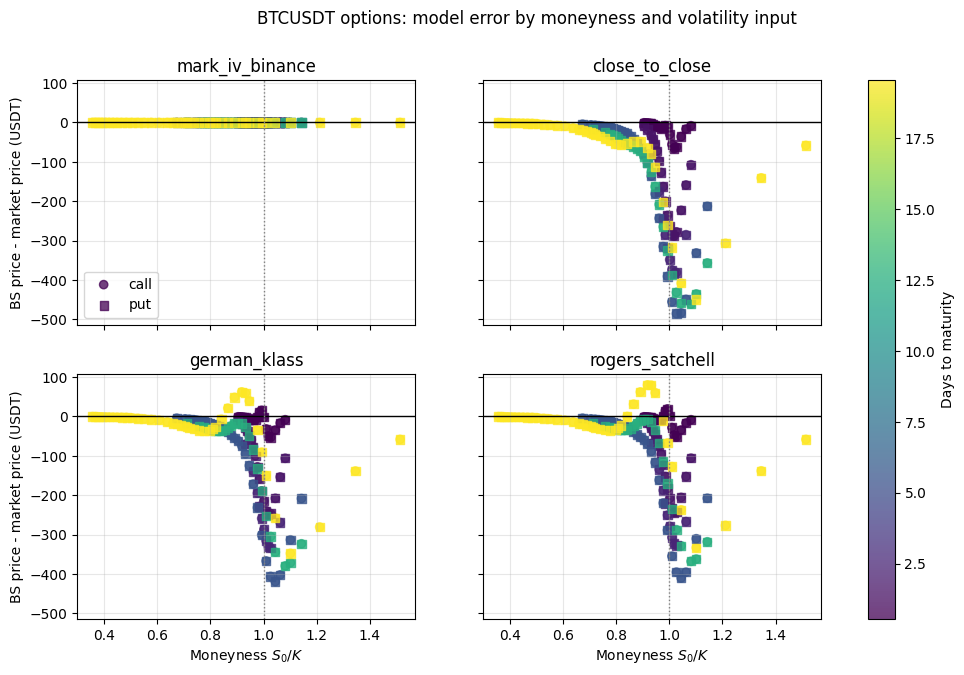

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.ravel()

for ax, volatility_source in zip(axes, volatility_order):
    subset = btc_chain_comparison[
        btc_chain_comparison["volatility_source"] == volatility_source
    ]
    for option_type, marker in [("call", "o"), ("put", "s")]:
        typed = subset[subset["option_type"] == option_type]
        scatter = ax.scatter(
            typed["moneyness"],
            typed["model_minus_market"],
            c=typed["maturity_days"],
            cmap="viridis",
            marker=marker,
            alpha=0.75,
            label=option_type,
        )
    ax.axhline(0.0, color="black", linewidth=1)
    ax.axvline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(volatility_source)
    ax.grid(True, alpha=0.3)

for ax in axes[2:]:
    ax.set_xlabel("Moneyness $S_0/K$")
for ax in axes[::2]:
    ax.set_ylabel("BS price - market price (USDT)")
axes[0].legend()
fig.colorbar(scatter, ax=axes.tolist(), label="Days to maturity")
fig.suptitle("BTCUSDT options: model error by moneyness and volatility input")
save_figure(fig, "btc_chain_error_by_moneyness.png")
plt.show()


The `mark_iv_binance` panel is almost flat around zero, which confirms that Binance mark IV is a calibration input tied to option prices.

The three historical-volatility panels show a different story. `close_to_close` produces the strongest underpricing, especially near the at-the-money region around `S_0/K = 1`. The `german_klass` and `rogers_satchell` panels shift many points closer to zero, so using OHLC range information helps. Still, the same curved structure remains: errors depend on moneyness and maturity, not only on the average volatility level.

This is the key visual result. Better historical estimators reduce the error, but they do not remove volatility smile, skew, and term-structure effects visible in the option chain.


To separate the maturity effect from the strike effect, the next step aggregates the same errors by expiry. For each expiry and volatility input, we calculate the median absolute pricing error across all contracts available for that expiry. The median is useful here because it gives a compact maturity-level summary without letting one extreme strike dominate the result.


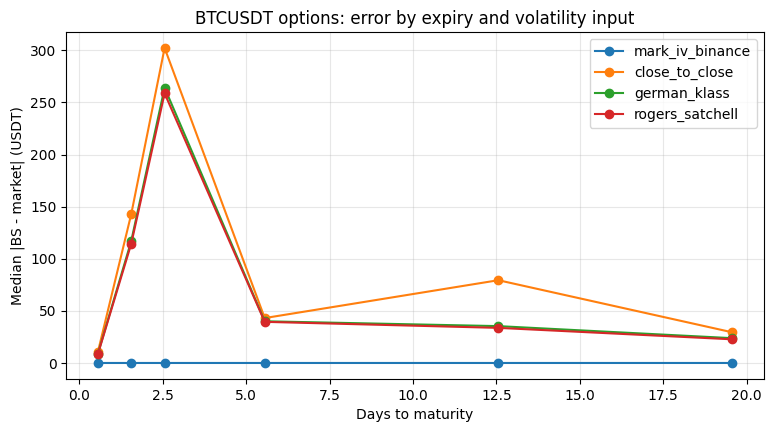

Volatility input,Days to maturity,Contracts,Median |BS - market|
mark_iv_binance,0.6,40,0.00
mark_iv_binance,1.6,36,0.00
mark_iv_binance,2.6,20,0.00
mark_iv_binance,5.6,62,0.00
mark_iv_binance,12.6,52,0.00
mark_iv_binance,19.6,84,0.00
close_to_close,0.6,40,10.45
close_to_close,1.6,36,142.85
close_to_close,2.6,20,302.31
close_to_close,5.6,62,43.11


In [20]:
maturity_summary = (
    btc_chain_comparison.groupby(["volatility_source", "expiry_utc"], as_index=False)
    .agg(
        maturity_days=("maturity_days", "mean"),
        contracts=("symbol", "nunique"),
        median_abs_error=("absolute_model_error", "median"),
    )
    .assign(order=lambda df: df["volatility_source"].map({name: i for i, name in enumerate(volatility_order)}))
    .sort_values(["order", "maturity_days"])
)

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)
for volatility_source in volatility_order:
    subset = maturity_summary[maturity_summary["volatility_source"] == volatility_source]
    ax.plot(
        subset["maturity_days"],
        subset["median_abs_error"],
        marker="o",
        label=volatility_source,
    )
ax.set_xlabel("Days to maturity")
ax.set_ylabel("Median |BS - market| (USDT)")
ax.set_title("BTCUSDT options: error by expiry and volatility input")
ax.grid(True, alpha=0.3)
ax.legend()
save_figure(fig, "btc_chain_error_by_maturity.png")
plt.show()

maturity_summary_display = pd.DataFrame(
    {
        "Volatility input": maturity_summary["volatility_source"],
        "Days to maturity": maturity_summary["maturity_days"].map(lambda value: f"{value:.1f}"),
        "Contracts": maturity_summary["contracts"].astype(int),
        "Median |BS - market|": maturity_summary["median_abs_error"].map(format_usdt),
    }
)

report_table(maturity_summary_display)


The expiry-level plot and table make the maturity effect explicit. `mark_iv_binance` stays at **0.00 USDT** for every expiry, again because it is calibrated from option prices.

Among the historical estimators, `rogers_satchell` performs best in this snapshot, followed closely by `german_klass`, while `close_to_close` is the weakest. The largest maturity-level error appears at the 2.6-day expiry: **302.31 USDT** for `close_to_close`, **264.10 USDT** for `german_klass`, and **258.77 USDT** for `rogers_satchell`. At the shortest 0.6-day expiry, the OHLC estimators also improve the error from **10.45 USDT** to about **8.36-8.75 USDT**.

The pattern is not monotonic, so the issue is not simply that longer options are harder to price. Each expiry has its own volatility level and strike structure. The table also shows that every expiry-level point aggregates many contracts, from **20** to **84**, so the pattern is not based on a single quote.

Overall, the maturity analysis supports the same conclusion as the moneyness plot: OHLC historical volatility estimators are better than a simple close-to-close estimate, but one historical volatility number per estimator is still too simple for the BTCUSDT option chain.


The final check below is numerical rather than economic. We compare the finite-difference PDE price with the exact Black-Scholes price on a small near-the-money subset to verify that the numerical solver is not the source of the market mismatch.


In [21]:
fd_check = (
    btc_chain_comparison[btc_chain_comparison["fd_price"].notna()][
        ["symbol", "volatility_source", "fd_minus_bs"]
    ]
    .assign(abs_fd_minus_bs=lambda df: df["fd_minus_bs"].abs())
)

fd_check_summary = pd.DataFrame(
    {
        "FD rows": [len(fd_check)],
        "Unique contracts": [fd_check["symbol"].nunique()],
        "Max |FD - BS|": [f"{fd_check['abs_fd_minus_bs'].max():.4f} USDT"],
    }
)

fd_by_input = (
    fd_check.groupby("volatility_source", as_index=False)
    .agg(
        max_fd_error=("abs_fd_minus_bs", "max"),
        median_fd_error=("abs_fd_minus_bs", "median"),
    )
    .assign(order=lambda df: df["volatility_source"].map({name: i for i, name in enumerate(volatility_order)}))
    .sort_values("order")
)
fd_by_input_display = pd.DataFrame(
    {
        "Volatility input": fd_by_input["volatility_source"],
        "Max |FD - BS|": fd_by_input["max_fd_error"].map(lambda value: f"{value:.4f}"),
        "Median |FD - BS|": fd_by_input["median_fd_error"].map(lambda value: f"{value:.4f}"),
    }
)

display(report_table(fd_check_summary))
report_table(fd_by_input_display)


FD rows,Unique contracts,Max |FD - BS|
32,8,0.1020 USDT


Volatility input,Max |FD - BS|,Median |FD - BS|
mark_iv_binance,0.0788,0.0003
close_to_close,0.1020,0.0005
german_klass,0.0956,0.0003
rogers_satchell,0.0947,0.0003


The finite-difference rows are a numerical consistency check, not a separate market theory. The check uses **8 near-the-money contracts** and four volatility inputs, which gives **32 finite-difference rows**. The maximum difference between the finite-difference price and the exact Black-Scholes price is only **0.1020 USDT**.

This error is tiny compared with the market errors observed above, especially the historical-volatility errors that reach tens or hundreds of USDT. Therefore the market disagreement should be interpreted as a limitation of the Black-Scholes assumptions and volatility input, not as a failure of the PDE discretization.


## L. Conclusions

The numerical part of the project behaves as expected. The finite-difference solver reproduces the exact Black-Scholes price very closely, and the market-section check gives a maximum finite-difference versus exact-formula difference of only **0.1020 USDT**. This is small compared with the market pricing differences, so the numerical PDE method is not the source of the disagreement.

The market comparison shows a clear difference between calibration and independent volatility estimation. When we use `mark_iv_binance`, the median pricing error is essentially **0.00 USDT**, because implied volatility is already extracted from market option prices. This confirms that the Black-Scholes formula can match quoted prices when the market-implied volatility is used as an input.

The more meaningful student-level test is the historical-volatility case. The basic `close_to_close` estimator gives a median absolute error of **53.53 USDT** and a median relative error of **-16.88%**. The OHLC estimators improve the result: `german_klass` lowers the median absolute error to **33.86 USDT**, and `rogers_satchell` lowers it to **31.29 USDT**. This is a useful practical finding, because it shows that daily high-low information matters for BTCUSDT volatility estimation.

However, even the best OHLC estimator is still far from the Binance implied-volatility benchmark. The average `mark_iv_binance` level is **65.26%**, while the historical estimates are only **42.95%**, **45.98%**, and **46.39%**. The market is therefore pricing more volatility than the recent spot history suggests.

The plots explain where the error comes from. Errors depend on both moneyness and maturity: near-the-money options are often underpriced by historical volatility inputs, and the expiry-level median errors vary strongly across maturities. This supports the practical market idea of volatility smile, skew, and term structure. A single constant volatility cannot describe all strikes and expiries at once.

The main project conclusion is therefore balanced. The Black-Scholes PDE and its finite-difference approximation are mathematically consistent and work well as a numerical method. For real BTCUSDT options, the simple historical-volatility input is too limited, even when improved with OHLC estimators. Market prices contain additional information about expected future volatility, strike-dependent demand, and maturity-specific risk that is summarized by implied volatility.

This comparison is based on one saved Binance snapshot of short-term BTCUSDT options, so it should be treated as a compact practical experiment rather than a full trading model. A natural extension would be to repeat the same analysis over many daily snapshots and build a small implied-volatility surface by strike and expiry.
